# E09 · Bringing your own code: JAX functions with gradients inside a PyMC model

| | |
|---|---|
| **Type** | Worked example - read, run, modify |
| **Data** | Hudson's Bay Company pelt records 1900-1920: snowshoe hare and Canadian lynx, thousands of pelts per year |
| **You will learn** | Why NUTS needs to see inside your function · writing a PyTensor `Op` by hand with a JAX `vjp` as its `pullback` · checking a gradient with `verify_grad` · the one-liner `pytensor.wrap_jax` and what it does for you · compiling the whole model to JAX (nutpie's JAX backend, NumPyro) and when an `Op` needs a `jax_funcify` registration · an ODE solver (hand-rolled RK4 with `lax.scan`, and diffrax) as the mean function of a model · honest timings · what goes wrong: multimodal ODE likelihoods, NaNs, float32, tracers, fork deadlocks |

Sooner or later the model you want is not made of PyMC building blocks. The mean function
is a simulator, an ODE solver, an optimiser, a neural network, or a colleague's library.
This notebook shows how to put such a function inside a PyMC model **without giving up
NUTS**, using JAX to supply the gradients. The application is the classic one: the
Lotka-Volterra predator-prey equations fitted to the lynx and hare pelt records.

Several names in this corner of the API changed recently. The ones that matter here:

| Older tutorials | This environment (PyMC 6.3 / PyTensor 3.3 / nutpie 0.16) |
|---|---|
| `Op.grad` or `Op.L_op` | **`Op.pullback`** (same arguments as `L_op`); the old names still work but warn |
| write two `Op`s and a `jax_funcify` by hand | **`pytensor.wrap_jax(f)`** does all three |
| default PyTensor backend is C | default is **Numba**; a Python `perform` runs in "object mode" |
| `nuts_sampler_kwargs={...}` | **`nuts={...}`**; the JAX backend is `pm.sample(backend="jax")` |

In [1]:
import time
import warnings

import arviz as az
import diffrax as dfx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor
import pytensor.tensor as pt
import scipy.integrate
from pytensor.gradient import verify_grad
from pytensor.graph import Apply, Op
from pytensor.link.jax.dispatch import jax_funcify

from pymc_challenges import data

# JAX defaults to float32. PyMC works in float64. Set this BEFORE creating any JAX array.
jax.config.update("jax_enable_x64", True)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")

print(f"PyMC {pm.__version__}, PyTensor {pytensor.__version__}, JAX {jax.__version__}, diffrax {dfx.__version__}")
print("default PyTensor linker:", type(pytensor.compile.mode.get_default_mode().linker).__name__)

PyMC 6.3.2, PyTensor 3.3.2, JAX 0.11.2, diffrax 0.7.2
default PyTensor linker: NumbaLinker


## 1 · The question and the data

The Hudson's Bay Company bought pelts from trappers for centuries, and the number of lynx
and snowshoe-hare pelts it took in each year is the textbook example of a predator-prey
cycle. The question: **are these cycles what the Lotka-Volterra equations predict, and
what growth, predation and death rates do the data imply?**

$$
\frac{du}{dt} = (\alpha - \beta v)\,u, \qquad \frac{dv}{dt} = (-\gamma + \delta u)\,v
$$

with $u$ hares and $v$ lynx. Hares grow at rate $\alpha$ and are eaten at rate $\beta v$;
lynx die at rate $\gamma$ and grow by $\delta u$ when there are hares to eat. There is no
closed-form solution: to get the populations at the observation years you must
*numerically integrate* the equations - and that is the external code PyMC cannot see into.

In [2]:
data.describe("lynx_hare")
pelts = data.load("lynx_hare")
obs = pelts[["Hare", "Lynx"]].to_numpy()  # column 0 = prey, column 1 = predator
pelts.describe().round(1)

lynx_hare: Annual lynx and snowshoe-hare pelts: the classic predator-prey cycle.
  source: Hudson's Bay Company pelt records 1900-1920 (thousands), via the Stan Lotka-Volterra case study.
  url:    https://raw.githubusercontent.com/stan-dev/example-models/master/knitr/lotka-volterra/hudson-bay-lynx-hare.csv


,Year,Lynx,Hare
count,21.0,21.0,21.0
mean,1910.0,20.2,34.1
std,6.2,16.7,21.4
min,1900.0,4.0,7.6
25%,1905.0,8.6,19.5
50%,1910.0,12.3,25.4
75%,1915.0,29.7,47.2
max,1920.0,59.4,77.4


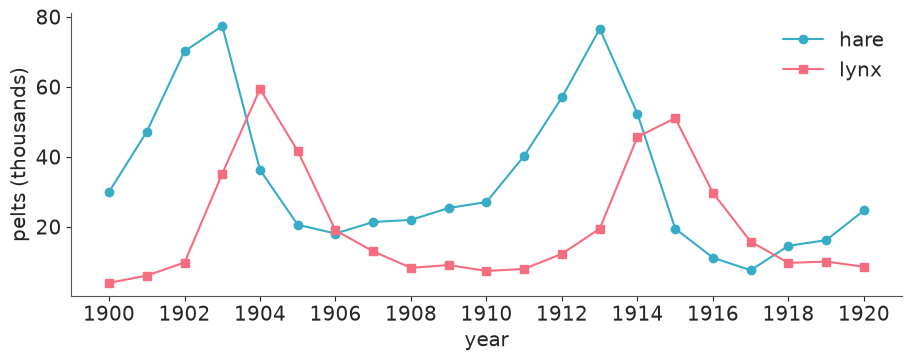

In [3]:
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(pelts.Year, pelts.Hare, "o-", label="hare")
ax.plot(pelts.Year, pelts.Lynx, "s-", label="lynx")
ax.set(xlabel="year", ylabel="pelts (thousands)", xticks=pelts.Year[::2])
ax.legend();

Two cycles of roughly ten years, with lynx peaking a year or two after the hares. Pelts
are a noisy proxy for population, and the noise is plausibly *multiplicative* (a good
trapping year scales everything), which is why the likelihood below is LogNormal.

## 2 · Why you cannot just call your function

NUTS needs the gradient of the log-density with respect to every parameter. PyMC gets it
by differentiating the **symbolic PyTensor graph** of the model. A PyMC random variable is
a node in that graph, not a number - so code that needs actual numbers fails the moment
you hand it one. We start with a function small enough to see through:
an exponential decay evaluated on a fixed grid of five times.

In [4]:
T_GRID = jnp.linspace(0.0, 4.0, 5)


def decay(a, k):
    """Two scalars in, a length-5 vector out."""
    return a * jnp.exp(-k * T_GRID)


print("with numbers:", decay(2.0, 0.5))

attempts = {
    "JAX function": lambda a, k: decay(a, k),
    "jnp.exp(k)": lambda a, k: jnp.exp(k),
    "float(k)": lambda a, k: float(k),
    "scipy solve_ivp": lambda a, k: scipy.integrate.solve_ivp(lambda t, y: -k * y, (0, 4), [1.0]),
}
with pm.Model():
    a_rv = pm.LogNormal("a", 0, 1)
    k_rv = pm.LogNormal("k", 0, 1)
    for label, attempt in attempts.items():
        try:
            attempt(a_rv, k_rv)
            print(f"{label:>16}: worked?!")
        except Exception as err:
            print(f"{label:>16}: {type(err).__name__}: {str(err).splitlines()[0][:110]}")

with numbers: [2.         1.21306132 0.73575888 0.44626032 0.27067057]
    JAX function: TypeError: unsupported operand type(s) for *: 'TensorVariable' and 'jaxlib._jax.ArrayImpl'
      jnp.exp(k): TypeError: Argument 'k' of type <class 'pytensor.tensor.variable.TensorVariable'> is not a valid JAX type.
        float(k): TypeError: TensorVariables cannot be converted to Python float. Call `.astype(float)` for the symbolic equivalent.
 scipy solve_ivp: ValueError: setting an array element with a sequence.


Every attempt fails, each in its own words, for the same reason: `k_rv` is a symbolic
`TensorVariable`. (Plain NumPy *arithmetic* on a random variable often appears to work,
because `TensorVariable` overloads `+`, `*`, `np.exp`... and quietly builds a graph. That
is PyTensor doing the work, not your function. Anything that loops, branches on values or
calls compiled code - a solver, in short - cannot be rescued that way.)

The way in is to teach PyTensor a new primitive: an **`Op`**. An `Op` tells PyTensor three
things: the types of its outputs (`make_node`), how to compute them from numbers
(`perform`), and how to build the graph of its gradient (`pullback`).

## 3 · Route 1 - write the `Op` by hand

You rarely need to do this any more (Route 2 is one line), but doing it once shows exactly
what the one-liner automates, and it is still the route for non-JAX code: if you have a
Fortran simulator with an adjoint, this is the template.

Reverse-mode differentiation never needs the full Jacobian $J$ of your function. It needs
the **vector-Jacobian product**: given the gradient of the final scalar (the log-density)
with respect to your *outputs*, $\bar{y}$, return the gradient with respect to your
*inputs*, $\bar{x} = \bar{y}^\top J$. JAX hands you exactly that function: `jax.vjp`.

In [5]:
decay_jit = jax.jit(decay)


@jax.jit
def decay_vjp(a, k, y_bar):
    _, pull = jax.vjp(decay, a, k)
    return pull(y_bar)  # a tuple: (a_bar, k_bar)


class DecayOp(Op):
    __props__ = ()  # no parameters: all instances are interchangeable, so PyTensor can merge them

    def make_node(self, a, k):
        # Declare input and output TYPES. Nothing is computed here. PyTensor trusts this
        # declaration: a wrong dtype or shape surfaces later as a confusing error, or not at all.
        a = pt.as_tensor(a, dtype="float64")
        k = pt.as_tensor(k, dtype="float64")
        return Apply(self, [a, k], [pt.tensor(dtype="float64", shape=(5,))])

    def perform(self, node, inputs, output_storage):
        # Called with NumPy arrays at run time. Must write a NumPy array of the declared dtype.
        a, k = inputs
        output_storage[0][0] = np.asarray(decay_jit(a, k), dtype="float64")

    def pullback(self, inputs, outputs, cotangents):
        # Called at GRAPH-BUILDING time with symbolic variables, so it cannot compute numbers.
        # It must return a graph - hence a second Op that will run the VJP later.
        a, k = inputs
        (y_bar,) = cotangents
        return decay_vjp_op(a, k, y_bar, return_list=True)


class DecayVJPOp(Op):
    __props__ = ()

    def make_node(self, a, k, y_bar):
        inputs = [pt.as_tensor(v, dtype="float64") for v in (a, k, y_bar)]
        return Apply(self, inputs, [pt.dscalar(), pt.dscalar()])  # two outputs: a_bar, k_bar

    def perform(self, node, inputs, output_storage):
        a_bar, k_bar = decay_vjp(*inputs)
        output_storage[0][0] = np.asarray(a_bar, dtype="float64")
        output_storage[1][0] = np.asarray(k_bar, dtype="float64")


decay_op = DecayOp()
decay_vjp_op = DecayVJPOp()

The `Op` now accepts symbolic variables. Compiling it produces one warning that you will
see in every project that uses a Python `perform`, so here it is once, on purpose:

In [6]:
a = pt.dscalar("a")
k = pt.dscalar("k")
y = decay_op(a, k)
print("symbolic output:", y, "of type", y.type)

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    f_decay = pytensor.function([a, k], y)
print("value:", f_decay(2.0, 0.5))
print("\nwarning:", str(caught[0].message)[:95], "...")

# silence it for the rest of the notebook
warnings.filterwarnings("ignore", message="Numba will use object mode")

symbolic output: DecayOp.0 of type Vector(float64, shape=(5,))


value: [2.         1.21306132 0.73575888 0.44626032 0.27067057]



PyTensor's default backend is now **Numba**. Numba cannot compile an arbitrary Python
`perform`, so it calls back into the interpreter for this one node ("object mode") and
compiles everything around it. That is harmless: the node is a jitted JAX call anyway. It
only means a little per-call overhead, which we will measure in section 8.

Now the gradient. `pt.grad` walks the graph backwards and, on reaching our node, calls
`pullback`. Printing the gradient graph shows the second `Op` sitting where the derivative
of `DecayOp` should be:

In [7]:
cost = (y**2).sum()
grad_a, grad_k = pt.grad(cost, [a, k])
pytensor.dprint(grad_k, depth=2);

DecayVJPOp.1 [id A]
 ├─ a [id B]
 ├─ k [id C]
 └─ Mul [id D]


The gradient with respect to `k` is output `.1` of a `DecayVJPOp` node with three inputs:
the original `a` and `k`, and a `Mul` sub-graph (collapsed here) that computes the
cotangent $\bar{y} = 2y$ - the derivative of `sum(y**2)` with respect to `y`, a length-5
vector like `y` itself. That node is what our `pullback` returned. The contract in full:

- `inputs`, `outputs`: the symbolic inputs and outputs of this node.
- `cotangents`: one symbolic variable **per output**, with that output's shape - the
  gradient of the final scalar with respect to it. (With several outputs, the ones the
  cost does not depend on arrive as `DisconnectedType`, and your code must cope.)
- return: one symbolic variable **per input**, with that input's shape.

Never trust a hand-written gradient until you have checked it. `verify_grad` compares it
with finite differences at random projections; we also compare with JAX's own Jacobian.

In [8]:
f_grad = pytensor.function([a, k], [grad_a, grad_k])
print("PyTensor gradient of sum(y^2):", [float(g) for g in f_grad(2.0, 0.5)])

jac_a, jac_k = jax.jacobian(decay, argnums=(0, 1))(2.0, 0.5)
y_val = decay(2.0, 0.5)
print("JAX: (2y) . J                :", [float(2 * y_val @ jac_a), float(2 * y_val @ jac_k)])

verify_grad(decay_op, [np.array(2.0), np.array(0.5)], rng=rng)
print("verify_grad: passed (it raises if the analytic and numeric gradients disagree)")

PyTensor gradient of sum(y^2): [6.285269726658612, -6.88939014642557]


JAX: (2y) . J                : [6.285269726658612, -6.88939014642557]


verify_grad: passed (it raises if the analytic and numeric gradients disagree)


### The classic pitfalls of Route 1

- **float32.** Without `jax_enable_x64`, JAX silently computes in single precision. Our
  `perform` casts the result to float64, which hides the problem instead of fixing it:

In [9]:
with jax.enable_x64(False):
    y32 = 2.0 * jnp.exp(-0.5 * jnp.linspace(0.0, 4.0, 5))
print("dtype without x64:", y32.dtype)
print("error after casting to float64:", np.abs(np.asarray(y32, dtype="float64") - np.asarray(y_val)).max())

dtype without x64: float32
error after casting to float64: 1.8299510462504998e-08


An error of 1e-8 in a value looks innocent. In the gradient of an ODE solution, accumulated
over hundreds of steps, it is enough to make NUTS reject good proposals for no visible
reason. Set the flag in the first cell, before any JAX array exists.

- **Type declarations are promises.** `make_node` said "float64 vector of length 5". If
  `perform` returns something else, the error appears far from its cause.
- **`jax.jit` compiles on the first call** for each new input shape/dtype. Jit once at module
  level (as above), not inside `perform`, or you pay compilation at every evaluation.
- **No second derivatives**: `DecayVJPOp` has no `pullback` of its own, so
  `pt.grad(grad_k, k)` raises `NotImplementedError`. NUTS does not need them; Laplace
  approximations and some optimisers do.
- **The old names.** If you implement `grad` or `L_op` as older tutorials say, PyTensor 3.3
  still calls it, with a `FutureWarning` telling you to rename it to `pullback`.

That is some forty lines for a one-line function, and it has to be repeated for each new
function. Hence:

## 4 · Route 2 - `pytensor.wrap_jax`

`wrap_jax` takes a JAX-jittable function and returns a function of PyTensor variables.

In [10]:
print(pytensor.wrap_jax.__doc__.split("Examples")[0])

Return a PyTensor-compatible function from a JAX jittable function.

    This decorator wraps a JAX function so that it accepts and returns
    `pytensor.Variable` objects. The JAX-jittable function can accept any
    nested Python structure (a `Pytree
    <https://jax.readthedocs.io/en/latest/pytrees.html>`_) as input, and might
    return any nested Python structure.

    Parameters
    ----------
    jax_function : Callable, optional
        A JAX function to be wrapped. If None, returns a decorator function.
    allow_eval : bool, default=True
        Whether to allow evaluation of symbolic shapes when input shapes are
        not fully determined.

    Returns
    -------
    Callable
        A function that wraps the given JAX function so that it can be called with
        pytensor.Variable inputs and returns pytensor.Variable outputs.

    


In [11]:
decay_wrapped = pytensor.wrap_jax(decay)

y2 = decay_wrapped(a, k)
op = y2.owner.op
print("Op class      :", type(op).__name__, f"(name={op.name!r})")
print("inferred input types :", op.input_types)
print("inferred output types:", op.output_types)

grads2 = pt.grad((y2**2).sum(), [a, k])
print("gradient Op   :", grads2[1].owner.op.name)
print("gradient value:", [float(g) for g in pytensor.function([a, k], grads2)(2.0, 0.5)])

Op class      : JAXOp (name='decay')
inferred input types : (TensorType(float64, shape=()), TensorType(float64, shape=()))
inferred output types: (TensorType(float64, shape=(5,)),)
gradient Op   : vjp_decay


gradient value: [6.285269726658612, -6.88939014642557]


Same numbers as the hand-written version, and the same construction underneath: a
`JAXOp` whose `perform` calls the jitted function and whose `pullback` creates a second
`JAXOp` (`vjp_decay`) that calls `jax.vjp`. What it did for us:

- **Output types by abstract evaluation.** It ran `jax.eval_shape` on dummy inputs to learn
  that two float64 scalars give a float64 vector of length 5. No declarations to get wrong.
- **Gradients of any order**, because the VJP `Op` is itself a `JAXOp`:

In [12]:
second = pt.grad(grads2[1], k)
print("d2/dk2 via wrap_jax:", float(second.eval({a: 2.0, k: 0.5})))
print("d2/dk2 via jax.hessian:", float(jax.hessian(lambda k_: (decay(2.0, k_) ** 2).sum())(0.5)))

d2/dk2 via wrap_jax: 26.405670586374644


d2/dk2 via jax.hessian: 26.405670586374644


- **Pytrees in and out.** Dicts, tuples, even Equinox modules holding PyTensor variables
  are flattened for you; non-array arguments are treated as static.

In [13]:
@pytensor.wrap_jax
def decay_summary(params, normalise=False):
    curve = params["a"] * jnp.exp(-params["k"] * T_GRID)
    if normalise:  # a plain Python bool: static, so an ordinary `if` is fine
        curve = curve / curve[0]
    return {"curve": curve, "area": jnp.trapezoid(curve, T_GRID)}


out = decay_summary({"a": a, "k": k})
print({name: str(var.type) for name, var in out.items()})

{'area': 'Scalar(float64, shape=())', 'curve': 'Vector(float64, shape=(5,))'}


### The limitation I actually hit: shapes must be known when the graph is built

`jax.eval_shape` needs concrete input shapes. A PyMC variable declared with `dims=` has a
*symbolic* length (so that `pm.set_data` can resize it). `wrap_jax` then evaluates the
shape once to get going, but **throws the static output shape away**; and if it cannot
evaluate the shape at all, it refuses:

In [14]:
cumsum_wrapped = pytensor.wrap_jax(lambda z: jnp.cumsum(z))

with pm.Model(coords={"species": ["hare", "lynx"]}):
    z_dims = pm.Normal("z_dims", dims="species")
    z_shape = pm.Normal("z_shape", shape=2)
    print("input declared with dims=    ->", cumsum_wrapped(z_dims).type)
    print("input declared with shape=2  ->", cumsum_wrapped(z_shape).type)
    print("dims= plus pt.specify_shape  ->", cumsum_wrapped(pt.specify_shape(z_dims, (2,))).type)

try:
    cumsum_wrapped(pt.vector("free_floating"))
except ValueError as err:
    print("\nno shape information at all  -> ValueError:", str(err)[:120])

input declared with dims=    -> Vector(float64, shape=(?,))
input declared with shape=2  -> Vector(float64, shape=(2,))
dims= plus pt.specify_shape  -> Vector(float64, shape=(2,))

no shape information at all  -> ValueError: Could not compile a function to infer example shapes. Please provide inputs with fully determined shapes by calling pt.s


An output of shape `(?,)` still runs, but PyTensor can no longer check shapes while the
graph is built, so mistakes surface at run time instead. The fix is one call to
`pt.specify_shape` at the boundary, which is what the model below does.

## 5 · Route 3 - stay in JAX end to end

So far PyTensor compiled the graph with Numba and called out to JAX for one node. But
PyTensor can also compile the **whole graph to JAX** (`mode="JAX"`). This is what happens
when you sample with NumPyro or with nutpie's JAX backend. Each `Op` is then translated by
a function registered with `jax_funcify`. Our hand-written `Op` has no translation:

In [15]:
try:
    pytensor.function([a, k], [cost, grad_a, grad_k], mode="JAX")
except NotImplementedError as err:
    print("NotImplementedError:", err)

NotImplementedError: No JAX conversion for the given `Op`: DecayOp


For Route 1 you must therefore register one yourself - trivial here, because the
implementation *is* a JAX function. `wrap_jax`'s `JAXOp` ships with its registration, so
Route 2 needs nothing.

In [16]:
@jax_funcify.register(DecayOp)
def _funcify_decay(op, **kwargs):
    return decay


@jax_funcify.register(DecayVJPOp)
def _funcify_decay_vjp(op, **kwargs):
    return decay_vjp


f_jax_manual = pytensor.function([a, k], [cost, grad_a, grad_k], mode="JAX")
f_jax_wrapped = pytensor.function([a, k], [(y2**2).sum(), *grads2], mode="JAX")
print("hand-written Op, JAX mode:", [float(v) for v in f_jax_manual(2.0, 0.5)])
print("wrap_jax,        JAX mode:", [float(v) for v in f_jax_wrapped(2.0, 0.5)])

hand-written Op, JAX mode: [6.285269726658612, 6.285269726658612, -6.88939014642557]
wrap_jax,        JAX mode: [6.285269726658612, 6.285269726658612, -6.88939014642557]


In JAX mode there is no callback and no copy between NumPy and JAX at the boundary: your
function is inlined into one XLA program together with the priors and the likelihood.
Whether that is *faster* depends on the model; we measure it on the real one below.

**Summary of the three routes**

| | hand-written `Op` | `wrap_jax` |
|---|---|---|
| default (Numba) backend, `pm.sample()` | works (object-mode callback) | works (object-mode callback) |
| JAX backend / NumPyro | only after `jax_funcify.register` | works |
| higher-order gradients | only if you write them | yes |
| non-JAX code (Fortran, C++, a web service...) | **yes - the reason to know Route 1** | no |

## 6 · The real function: a Lotka-Volterra solver in JAX

Two design decisions before any code.

**Integrate the logarithms.** With $x = \log u$, $y = \log v$ the equations become
$\dot{x} = \alpha - \beta e^{y}$, $\dot{y} = -\gamma + \delta e^{x}$. Populations are then
positive by construction, and the solver returns exactly what a LogNormal likelihood wants
as its location. Section 10 shows what happens if you do not do this.

**Two solvers.** A hand-rolled fixed-step RK4 written with `jax.lax.scan` (twenty steps per
year), and diffrax's adaptive `Tsit5`. `lax.scan` is the key to the first: a Python `for`
loop would be unrolled into thousands of operations at trace time, and `lax.while_loop`
cannot be reverse-differentiated at all. diffrax solves the same problem for adaptive
step sizes with a bounded, checkpointed loop (`RecursiveCheckpointAdjoint`, the default) or
by integrating the adjoint ODE backwards in time (`BacksolveAdjoint`).

In [17]:
N_YEARS = len(pelts) - 1  # 20 intervals; t = 0 is the year 1900
T_OBS = jnp.arange(N_YEARS + 1.0)


def lv_rhs(t, log_z, theta):
    alpha, beta, gamma, delta = theta
    hare, lynx = jnp.exp(log_z)
    return jnp.stack([alpha - beta * lynx, -gamma + delta * hare])


def make_rk4(saves_per_year=1, substeps=20):
    """Classic RK4 with a fixed step of 1 / (saves_per_year * substeps) years."""
    dt = 1.0 / (saves_per_year * substeps)

    def solve(theta, z0):
        def substep(log_z, _):
            k1 = lv_rhs(0.0, log_z, theta)
            k2 = lv_rhs(0.0, log_z + 0.5 * dt * k1, theta)
            k3 = lv_rhs(0.0, log_z + 0.5 * dt * k2, theta)
            k4 = lv_rhs(0.0, log_z + dt * k3, theta)
            return log_z + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4), None

        def to_next_save(log_z, _):
            log_z, _ = jax.lax.scan(substep, log_z, None, length=substeps)
            return log_z, log_z

        log_z0 = jnp.log(z0)
        _, path = jax.lax.scan(to_next_save, log_z0, None, length=N_YEARS * saves_per_year)
        return jnp.concatenate([log_z0[None], path])  # (n_saves + 1, 2): log hare, log lynx

    return solve


def make_diffrax(solver=None, adjoint=None, tol=1e-6, max_steps=4096, throw=False):
    solver = dfx.Tsit5() if solver is None else solver
    adjoint = dfx.RecursiveCheckpointAdjoint() if adjoint is None else adjoint

    def solve(theta, z0):
        sol = dfx.diffeqsolve(
            dfx.ODETerm(lv_rhs), solver, t0=0.0, t1=float(N_YEARS), dt0=0.1, y0=jnp.log(z0), args=theta,
            saveat=dfx.SaveAt(ts=T_OBS),  # return the solution at the observation years only
            stepsize_controller=dfx.PIDController(rtol=tol, atol=tol),
            adjoint=adjoint, max_steps=max_steps, throw=throw,
        )
        return sol.ys

    return solve


lv_rk4 = make_rk4()
lv_tsit5 = make_diffrax()
lv_tsit5_backsolve = make_diffrax(adjoint=dfx.BacksolveAdjoint())

Check the solvers against a reference (an 8th-order method at tolerance 1e-12), and time
what NUTS will actually call: the value **and gradient**. The point is a plausible one:
rates from the Stan case study on these data, starting from the first observation.

In [18]:
theta_ref = jnp.array([0.55, 0.028, 0.80, 0.024])
z0_ref = jnp.asarray(obs[0])
reference = make_diffrax(dfx.Dopri8(), tol=1e-12)(theta_ref, z0_ref)
weights = jnp.asarray(rng.normal(size=reference.shape))  # a random cotangent


def time_solver(solve, n=200):
    value_and_grad = jax.jit(jax.value_and_grad(lambda th, z: (solve(th, z) * weights).sum(), argnums=(0, 1)))
    start = time.perf_counter()
    value_and_grad(theta_ref, z0_ref)[0].block_until_ready()
    first = time.perf_counter() - start
    start = time.perf_counter()
    for _ in range(n):
        value_and_grad(theta_ref, z0_ref)[0].block_until_ready()
    per_call = (time.perf_counter() - start) / n
    return {
        "max abs error (log scale)": float(jnp.abs(solve(theta_ref, z0_ref) - reference).max()),
        "first call incl. jit (s)": round(first, 2),
        "value+grad per call (ms)": round(per_call * 1e3, 3),
    }


solver_table = pd.DataFrame({
    "RK4, 20 steps/year, lax.scan": time_solver(lv_rk4),
    "diffrax Tsit5, checkpointed adjoint": time_solver(lv_tsit5),
    "diffrax Tsit5, backsolve adjoint": time_solver(lv_tsit5_backsolve),
}).T
solver_table["max abs error (log scale)"] = solver_table["max abs error (log scale)"].map("{:.1e}".format)
solver_table

,max abs error (log scale),first call incl. jit (s),value+grad per call (ms)
"RK4, 20 steps/year, lax.scan",4.4e-07,0.15,0.367
"diffrax Tsit5, checkpointed adjoint",1.8e-05,1.01,0.847
"diffrax Tsit5, backsolve adjoint",1.8e-05,1.00,0.216


All three are far more accurate than the data warrant. The timings (they vary from run to
run, and this notebook was built on a busy machine, so read ratios, not digits) show the
pattern you should expect. The **first call is dominated by compilation**: hundreds to
thousands of times the cost of a later call. On a problem this small and smooth the
fixed-step scan is as cheap to differentiate as anything; diffrax's default checkpointed
adjoint costs three to four times more, and its backsolve adjoint closes the gap. (The
backsolve gradient is that of the continuous adjoint ODE, not exactly the derivative of
the numbers the forward solve produced, which is why diffrax does not make it the
default.) An adaptive solver earns its keep when the dynamics are stiff or the right
step size varies wildly across the prior.

## 7 · The model

$$
\begin{aligned}
\log \text{pelts}_{t,s} &\sim \text{Normal}\big(\log z_s(t;\,\theta, z_0),\ \sigma_s\big)
  \qquad s \in \{\text{hare}, \text{lynx}\} \\
z(t) &= \text{solution of the Lotka-Volterra equations from } z_0 \text{ with rates } \theta
\end{aligned}
$$

Priors, on the scale of the data (thousands of pelts, years):

- $\alpha, \gamma \sim \text{LogNormal}(\log 1, 0.5)$: rates "per year" of order one. Hares
  can plausibly multiply by $e$ in a good year with no predators; lynx without prey starve
  within a year or so. The prior puts 90% of its mass between about 0.4 and 2.3.
- $\beta, \delta \sim \text{LogNormal}(\log 0.05, 1)$: the equilibrium of the system is
  $(u^\*, v^\*) = (\gamma/\delta,\ \alpha/\beta)$. With pelts in the tens of thousands, that
  equilibrium should sit somewhere between a few and a few hundred, so the interaction
  rates are of order $1/20$, give or take a factor of several.
- $z_0 \sim \text{LogNormal}(\log 10, 1)$: initial populations of order ten thousand pelts.
- $\sigma \sim \text{LogNormal}(-1, 1)$: multiplicative noise of roughly 10% to 100%.

The initial state is a *parameter*: the 1900 observation is as noisy as any other.

In [19]:
RATES = ["alpha", "beta", "gamma", "delta"]


def build_model(solver):
    solver_pt = pytensor.wrap_jax(solver)
    coords = {"year": pelts.Year.values, "species": ["hare", "lynx"]}
    with pm.Model(coords=coords) as model:
        alpha = pm.LogNormal("alpha", np.log(1.0), 0.5)
        beta = pm.LogNormal("beta", np.log(0.05), 1.0)
        gamma = pm.LogNormal("gamma", np.log(1.0), 0.5)
        delta = pm.LogNormal("delta", np.log(0.05), 1.0)
        z0 = pm.LogNormal("z0", np.log(10.0), 1.0, dims="species")
        sigma = pm.LogNormal("sigma", -1.0, 1.0, dims="species")

        theta = pt.stack([alpha, beta, gamma, delta])
        # the boundary: a static shape for z0 (section 4), then straight into JAX
        log_mu = solver_pt(theta, pt.specify_shape(z0, (2,)))
        pm.Deterministic("mu", pt.exp(log_mu), dims=("year", "species"))

        pm.LogNormal("pelts", log_mu, sigma, observed=obs, dims=("year", "species"))
    return model


model = build_model(lv_rk4)
model

### Prior predictive: trajectories, not parameters

Priors on ODE parameters are impossible to judge one at a time - what matters is the
*trajectories* they imply. Nothing needs gradients here, so this also confirms that the
wrapped function works in plain forward sampling.

In [20]:
with model:
    prior = pm.sample_prior_predictive(500, random_seed=RANDOM_SEED)

prior_mu = prior.prior["mu"].sel(chain=0)
peak = prior_mu.max(("year", "species"))
print("prior trajectories containing non-finite values:", int((~np.isfinite(prior_mu)).any(("year", "species")).sum()))
print("share of prior trajectories peaking above 1,000 (a million pelts):", float((peak > 1000).mean().round(3)))
print("share staying below 1 (a thousand pelts) at some point:",
      float((prior_mu.min(("year", "species")) < 1).mean().round(3)))

Sampling: [alpha, beta, delta, gamma, pelts, sigma, z0]


prior trajectories containing non-finite values: 0
share of prior trajectories peaking above 1,000 (a million pelts): 0.034
share staying below 1 (a thousand pelts) at some point: 0.528


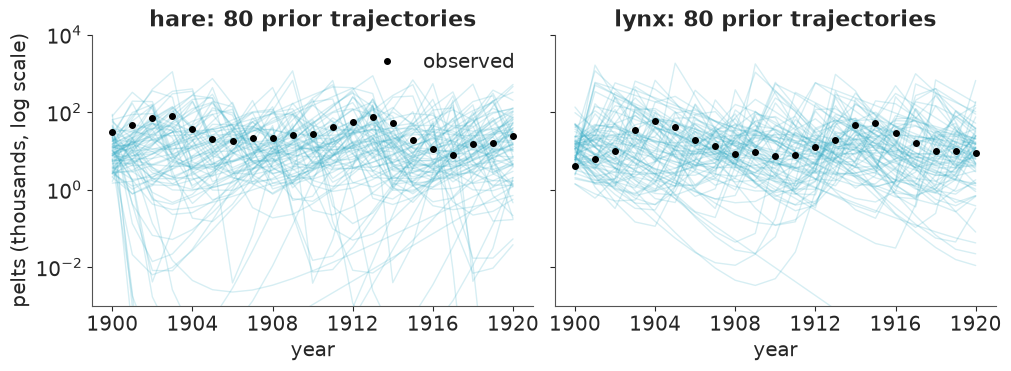

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharey=True)
for ax, species in zip(axes, ["hare", "lynx"]):
    ax.plot(pelts.Year, prior_mu.sel(species=species).values[:80].T, color="C0", alpha=0.2, lw=1)
    ax.plot(pelts.Year, pelts[species.capitalize()], "ko", ms=4, label="observed")
    ax.set(yscale="log", ylim=(1e-3, 1e4), title=f"{species}: 80 prior trajectories", xlabel="year",
           xticks=pelts.Year[::4])
axes[0].set_ylabel("pelts (thousands, log scale)")
axes[0].legend();

The prior covers the data with room to spare. It includes oscillations of every period and
amplitude; a few percent of the trajectories peak above a million pelts, and about half
dip below a thousand at some point, some of them far below the bottom of the axis (which
is clipped at a single pelt). That is wider than anyone believes, but it rules out nothing
plausible, and no draw broke the solver. Good enough to proceed.

## 8 · Fit - and the first thing that goes wrong

Default settings first. `pm.sample()` uses nutpie with the Numba backend here, so the
solver and its VJP run as object-mode callbacks (Route 2).

In [22]:
with model:
    idata_default = pm.sample(random_seed=RANDOM_SEED, progressbar=False)


def chain_report(idata):
    post, stats = idata.posterior, idata.sample_stats
    return pd.DataFrame({
        "divergences": stats["diverging"].sum("draw").values,
        "step size": stats["step_size"].isel(draw=-1).values.round(2),
        "mean alpha": post["alpha"].mean("draw").values.round(2),
        "mean gamma": post["gamma"].mean("draw").values.round(2),
        "mean sigma_hare": post["sigma"].sel(species="hare").mean("draw").values.round(2),
    }).rename_axis("chain")


chain_report(idata_default)

NUTS[nutpie]: [alpha, beta, gamma, delta, z0, sigma]


,divergences,step size,mean alpha,mean gamma,mean sigma_hare
chain,,,,,
0,101,0.38,0.55,0.87,0.27
1,0,0.34,0.55,0.79,0.25
2,0,0.36,0.55,0.80,0.25
3,0,0.33,0.55,0.80,0.25


In [23]:
az.summary(idata_default, var_names=[*RATES, "z0", "sigma"], round_to=3)[["mean", "sd", "ess_bulk", "ess_tail", "r_hat"]]

,mean,sd,ess_bulk,ess_tail,r_hat
alpha,0.550,0.103,44.332,115.794,1.077
beta,0.028,0.008,101.488,208.472,1.046
gamma,0.814,0.102,43.895,209.791,1.070
delta,0.024,0.004,102.104,223.092,1.111
z0[hare],34.365,3.471,124.629,138.196,1.038
z0[lynx],6.067,1.200,49.892,118.111,1.058
sigma[hare],0.253,0.069,25.364,26.695,1.100
sigma[lynx],0.265,0.086,22.809,25.741,1.143


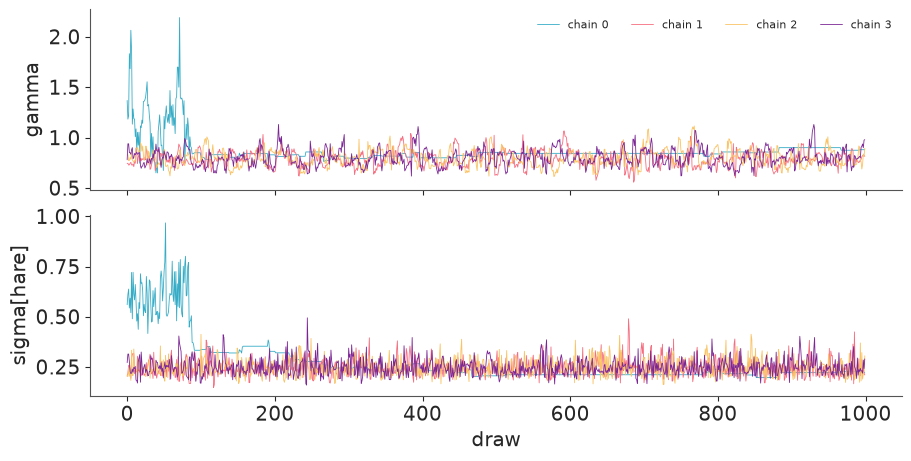

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(9, 4.5), sharex=True)
for chain in idata_default.posterior.chain.values:
    axes[0].plot(idata_default.posterior["gamma"].sel(chain=chain), lw=0.6, label=f"chain {chain}")
    axes[1].plot(idata_default.posterior["sigma"].sel(chain=chain, species="hare"), lw=0.6)
axes[0].set(ylabel="gamma")
axes[1].set(ylabel="sigma[hare]", xlabel="draw")
axes[0].legend(ncols=4, fontsize=8);

That is a failed fit: divergences, $\hat{R}$ up to 1.14, and a bulk ESS in the twenties
for `sigma`. The per-chain table and the traces show what happened. Three chains agree.
Chain 0 was still somewhere else when warm-up ended - `gamma` between 1 and 2, `sigma`
two to three times larger, i.e. a poor fit explained away as noise. It dropped into
the main mode after about 90 draws, but it never mixes properly afterwards: long flat
stretches where it does not move at all, and all 101 divergences are its own. Its warm-up
was spent adapting to a different region, so its step size and mass matrix are presumably
wrong for this one. While preparing this notebook I ran this default fit with eight
different seeds: five of them had at least one chain like this, some stuck in the wrong
mode for the entire run.

The cause is not the JAX plumbing - it is the *likelihood of an oscillator*. If the model's
period is wrong, the simulated cycles drift in and out of phase with the data, and the fit
has many local optima: parameter values where at least some peaks line up. A one-dimensional
slice shows it. Set $\alpha = \gamma = \omega$ (so the period of small oscillations is
$2\pi/\omega$), fix the equilibrium at the observed mean populations, start from the first
observation, and scan $\omega$:

local minima at omega = [0.7  1.15 1.6  1.69 1.76 1.87 1.97] with SSE [ 6.6 40.  59.9 57.5 56.4 59.2 59.4]


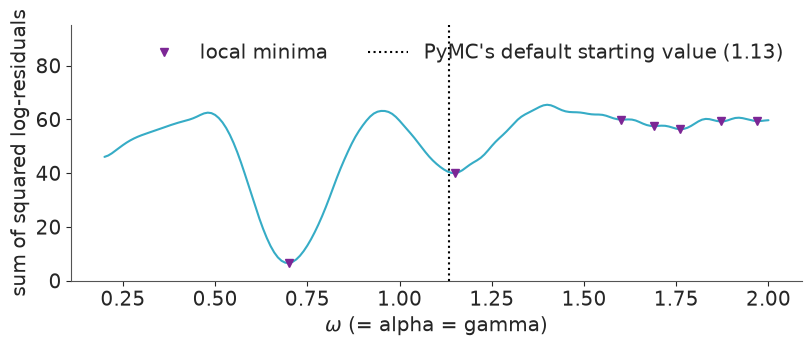

In [25]:
log_obs = jnp.log(obs)
mean_hare, mean_lynx = obs.mean(axis=0)


def sse_slice(omega):
    theta = jnp.stack([omega, omega / mean_lynx, omega, omega / mean_hare])
    return ((lv_rk4(theta, jnp.asarray(obs[0])) - log_obs) ** 2).sum()


omegas = jnp.linspace(0.2, 2.0, 181)
sse = np.asarray(jax.vmap(sse_slice)(omegas))  # vmap: 181 ODE solves in one call
is_min = np.r_[False, (sse[1:-1] < sse[:-2]) & (sse[1:-1] < sse[2:]), False]

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(omegas, sse)
ax.plot(omegas[is_min], sse[is_min], "v", color="C3", label="local minima")
default_start = float(np.exp(model.initial_point()["alpha_log__"]))
ax.axvline(default_start, color="k", ls=":", label=f"PyMC's default starting value ({default_start:.2f})")
ax.set(xlabel=r"$\omega$ (= alpha = gamma)", ylabel="sum of squared log-residuals")
ax.set_ylim(0, 95)
ax.legend(loc="upper right", ncols=2)
print("local minima at omega =", np.round(np.asarray(omegas)[is_min], 2), "with SSE", sse[is_min].round(1))

The global minimum is at $\omega \approx 0.70$ (a period of about nine years). But there is
a second basin at $\omega \approx 1.15$, where the model cycles faster than the data and
only some of the peaks line up, and a string of shallow ones beyond. And PyMC's default starting
value for a `LogNormal(0, 0.5)` rate is 1.13 - at the bottom of the wrong basin. This
is only a one-dimensional slice of an eight-dimensional surface, but it is the right
picture: a gradient-based sampler started there has no reason to leave quickly.

### The fix: start where the physics says, and tell the sampler about the correlations

Lotka-Volterra hands us a rough answer for free. Over a full cycle the *time-averages* of
the populations equal the equilibrium values, $\bar{u} = \gamma/\delta$ and
$\bar{v} = \alpha/\beta$, and small oscillations have period $2\pi/\sqrt{\alpha\gamma}$.
The plot in section 1 shows a period of about ten years. So:

In [26]:
omega0 = 2 * np.pi / 10
initvals = {
    "alpha": omega0,
    "gamma": omega0,
    "beta": omega0 / mean_lynx,
    "delta": omega0 / mean_hare,
    "z0": obs[0],
}
{name: np.round(value, 3) for name, value in initvals.items()}

{'alpha': np.float64(0.628),
 'gamma': np.float64(0.628),
 'beta': np.float64(0.031),
 'delta': np.float64(0.018),
 'z0': array([30.,  4.])}

Two more settings, both specific to nutpie:

- nutpie adds uniform(-1, 1) jitter to the starting point *on the unconstrained scale*. For
  a log-transformed rate that is a factor of up to $e$ either way - enough to throw a
  chain into a neighbouring mode. `compile_kwargs={"jitter_rvs": set()}` switches it off.
  The price: all chains start from the same point, so $\hat{R}$ is a weaker check than
  usual. The rank plots and a second sampler (NumPyro, below) back it up.
- `nuts={"adaptation": "low_rank"}` adapts a low-rank-plus-diagonal mass matrix instead of
  a diagonal one. Section 9 shows why that matters here: the rates are strongly correlated.

We also time every fit from here on, *including compilation*, for the comparison below.

In [27]:
timings = {}


def timed_sample(label, model, **kwargs):
    start = time.perf_counter()
    with model:
        idata = pm.sample(random_seed=RANDOM_SEED, initvals=initvals, progressbar=False, **kwargs)
    wall = time.perf_counter() - start
    ess = az.summary(idata, var_names=[*RATES, "z0", "sigma"])["ess_bulk"].min()
    timings[label] = {
        "wall time incl. compile (s)": round(wall, 1),
        "sampling time reported (s)": round(float(idata.posterior.attrs["sampling_time"]), 1),
        "divergences": int(idata.sample_stats["diverging"].sum()),
        "min bulk ESS": int(ess),
        "min ESS per wall-second": int(ess / wall),
    }
    return idata


idata = timed_sample(
    "nutpie, Numba backend (JAX via callback)", model,
    nuts={"adaptation": "low_rank"}, compile_kwargs={"jitter_rvs": set()},
)
chain_report(idata)

NUTS[nutpie]: [alpha, beta, gamma, delta, z0, sigma]


,divergences,step size,mean alpha,mean gamma,mean sigma_hare
chain,,,,,
0,0,0.81,0.55,0.79,0.25
1,0,0.75,0.55,0.79,0.25
2,0,0.78,0.55,0.79,0.25
3,0,0.76,0.55,0.79,0.25


In [28]:
az.summary(idata, var_names=[*RATES, "z0", "sigma"], ci_kind="hdi", ci_prob=0.94, round_to=3)

,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,0.553,0.062,0.438,0.668,4097.308,2897.108,1.002,0.001,0.001
beta,0.028,0.004,0.021,0.036,4821.003,3188.031,1.002,0.000,0.000
gamma,0.791,0.086,0.634,0.951,4149.429,2871.567,1.002,0.001,0.002
delta,0.024,0.003,0.017,0.030,3967.576,2868.424,1.000,0.000,0.000
z0[hare],34.114,2.902,28.825,39.521,4574.386,3387.099,1.001,0.043,0.045
z0[lynx],5.966,0.523,4.985,6.942,3510.634,2639.978,1.002,0.009,0.011
sigma[hare],0.248,0.044,0.175,0.332,3634.642,2612.732,1.000,0.001,0.001
sigma[lynx],0.251,0.043,0.176,0.332,3949.700,3027.984,1.000,0.001,0.001


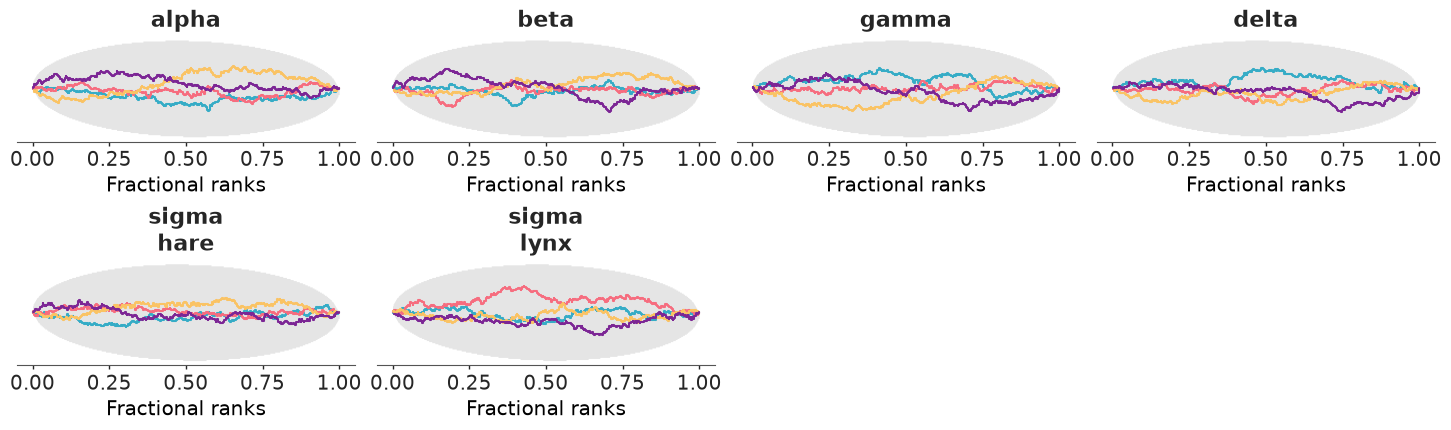

In [29]:
az.plot_rank(idata, var_names=[*RATES, "sigma"], method="envelope");

No divergences, $\hat{R} \le 1.002$, bulk ESS above 3500 for every parameter from 4000
draws, all four chains with similar step sizes, and the rank plots stay inside the
envelope expected for chains that sample the same distribution. The posterior means
($\alpha \approx 0.55$, $\beta \approx 0.028$, $\gamma \approx 0.79$, $\delta \approx 0.024$,
$\sigma \approx 0.25$) agree with the Stan case study on the same data.

### The same model, three ways of running it

Now the comparison promised in section 5. All runs use the same model object, the same
starting point, no jitter, and the default 4 x (1000 + 1000) draws.

- **nutpie, Numba backend** (above): PyTensor differentiates the graph; the solver and its
  VJP are `JAXOp` callbacks.
- **nutpie, Numba backend, diagonal mass matrix**: as above with the default adaptation, to
  show what `low_rank` bought.
- **nutpie, JAX backend**: `backend="jax"` compiles the whole log-density to one XLA
  program; `gradient_backend="jax"` lets `jax.grad` differentiate it, solver included.
  (`nuts_sampler_kwargs={"backend": "jax"}` is the old spelling and now warns.)
- **NumPyro**: the sampler itself is JAX too. `dense_mass=True` is its counterpart of
  a non-diagonal mass matrix. With one CPU device it runs the four chains one after another
  (the warning below says so), whereas nutpie runs them in parallel threads.
- **nutpie, JAX backend, diffrax**: swap the solver for adaptive `Tsit5`.

In [30]:
warnings.filterwarnings("ignore", message="Skipping `?Check")  # JAX mode drops PyMC's parameter checks, and says so

idata_diag = timed_sample(
    "nutpie, Numba backend, diagonal mass matrix", model,
    compile_kwargs={"jitter_rvs": set()},
)
idata_nutpie_jax = timed_sample(
    "nutpie, JAX backend", model,
    nuts_sampler="nutpie", backend="jax", nuts={"adaptation": "low_rank"},
    compile_kwargs={"gradient_backend": "jax", "jitter_rvs": set()},
)
idata_numpyro = timed_sample(
    "NumPyro (chains run sequentially)", model,
    nuts_sampler="numpyro", nuts={"jitter": False, "dense_mass": True},
)
model_diffrax = build_model(lv_tsit5)
idata_diffrax = timed_sample(
    "nutpie, JAX backend, diffrax Tsit5", model_diffrax,
    nuts_sampler="nutpie", backend="jax", nuts={"adaptation": "low_rank"},
    compile_kwargs={"gradient_backend": "jax", "jitter_rvs": set()},
)

def timing_table():
    table = pd.DataFrame(timings).T
    int_cols = ["divergences", "min bulk ESS", "min ESS per wall-second"]
    return table.astype({col: int for col in int_cols})


timing_table()

NUTS[nutpie]: [alpha, beta, gamma, delta, z0, sigma]


NUTS[nutpie]: [alpha, beta, gamma, delta, z0, sigma]


NUTS[numpyro]: [alpha, beta, gamma, delta, z0, sigma]


/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/pymc/sampling/jax.py:463: UserWarning: There are not enough devices to run parallel chains: expected 4 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(4)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  pmap_numpyro = MCMC(


NUTS[nutpie]: [alpha, beta, gamma, delta, z0, sigma]


,wall time incl. compile (s),sampling time reported (s),divergences,min bulk ESS,min ESS per wall-second
"nutpie, Numba backend (JAX via callback)",7.5,6.1,0,3510,469
"nutpie, Numba backend, diagonal mass matrix",14.4,13.0,0,799,55
"nutpie, JAX backend",4.9,4.7,0,3339,679
NumPyro (chains run sequentially),12.3,11.8,0,4204,342
"nutpie, JAX backend, diffrax Tsit5",14.0,13.8,0,4011,286


In [31]:
runs = {"nutpie/Numba": idata, "nutpie/Numba diag": idata_diag, "nutpie/JAX": idata_nutpie_jax,
        "NumPyro": idata_numpyro, "nutpie/JAX diffrax": idata_diffrax}
pd.DataFrame({
    label: {**{r: float(run.posterior[r].mean()) for r in RATES},
            "sigma_hare": float(run.posterior["sigma"].sel(species="hare").mean())}
    for label, run in runs.items()
}).T.round(4)

,alpha,beta,gamma,delta,sigma_hare
nutpie/Numba,0.5526,0.0280,0.7912,0.0237,0.2485
nutpie/Numba diag,0.5513,0.0279,0.7928,0.0238,0.2469
nutpie/JAX,0.5541,0.0281,0.7891,0.0237,0.2478
NumPyro,0.5543,0.0281,0.7885,0.0237,0.2473
nutpie/JAX diffrax,0.5553,0.0281,0.7878,0.0236,0.2482


Every run is clean and the posterior means agree to two or three significant figures, so
the routes differ only in cost. Timings change from run to run (this page was built
while other jobs were running), so read the ratios:

- **The two nutpie backends are about equally fast** on this model: the same sampling
  time, with the JAX backend roughly a second ahead in total because it compiles faster.
  The object-mode callback of Route 2 is not the bottleneck you might fear.
- **NumPyro takes two to three times longer**, almost entirely because it runs the four
  chains one after another on a single CPU device, while nutpie runs them in parallel.
  Its ESS is as good or better; per chain it is competitive.
- **The mass matrix mattered more than the backend.** With the default diagonal adaptation
  the same model takes about twice as long and yields less than a quarter of the
  effective draws: roughly a tenth of the ESS per second.
- **diffrax costs about three times more** than the hand-rolled RK4, for the same posterior.
  That is the price of adaptive step-size control on a problem that does not need it.

One more number, because sampling times mix the cost of a gradient with how many gradients
the sampler chose to take. Below: the cost of **one** log-density-and-gradient evaluation
of the compiled model in each mode - and, for contrast, the same model written with PyMC's
built-in `pm.ode.DifferentialEquation`, which integrates the ODE *and its forward
sensitivities* with SciPy's `odeint`.

In [32]:
def time_logp_grad(model, mode, n=200):
    logp = model.logp()
    grads = pt.grad(logp, model.value_vars)
    start = time.perf_counter()
    fn = pytensor.function(model.value_vars, [logp, *grads], mode=mode)
    point = model.initial_point()
    args = [point[v.name] for v in model.value_vars]
    fn(*args)
    compile_time = time.perf_counter() - start
    start = time.perf_counter()
    for _ in range(n):
        fn(*args)
    return {"compile + first call (s)": round(compile_time, 2),
            "logp and gradient, per call (ms)": round((time.perf_counter() - start) / n * 1e3, 3)}


def lv_rhs_pymc(y, t, p):  # natural scale, as the PyMC docs write it
    return [(p[0] - p[1] * y[1]) * y[0], (-p[2] + p[3] * y[0]) * y[1]]


with pm.Model() as model_pm_ode:
    alpha = pm.LogNormal("alpha", np.log(1.0), 0.5)
    beta = pm.LogNormal("beta", np.log(0.05), 1.0)
    gamma = pm.LogNormal("gamma", np.log(1.0), 0.5)
    delta = pm.LogNormal("delta", np.log(0.05), 1.0)
    z0 = pm.LogNormal("z0", np.log(10.0), 1.0, shape=2)
    sigma = pm.LogNormal("sigma", -1.0, 1.0, shape=2)
    ode = pm.ode.DifferentialEquation(func=lv_rhs_pymc, times=np.arange(1.0, N_YEARS + 1), n_states=2, n_theta=4, t0=0)
    trajectory = pt.concatenate([z0[None, :], ode(y0=z0, theta=[alpha, beta, gamma, delta])])
    pm.LogNormal("pelts", pt.log(trajectory), sigma, observed=obs)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", FutureWarning)  # pm.ode still implements the deprecated `grad`
    logp_table = pd.DataFrame({
        "wrap_jax RK4, Numba mode": time_logp_grad(model, "NUMBA"),
        "wrap_jax RK4, JAX mode": time_logp_grad(model, "JAX"),
        "wrap_jax diffrax, Numba mode": time_logp_grad(model_diffrax, "NUMBA"),
        "wrap_jax diffrax, JAX mode": time_logp_grad(model_diffrax, "JAX"),
        "pm.ode.DifferentialEquation, Numba mode": time_logp_grad(model_pm_ode, "NUMBA", n=20),
    }).T
logp_table

,compile + first call (s),"logp and gradient, per call (ms)"
"wrap_jax RK4, Numba mode",0.89,0.268
"wrap_jax RK4, JAX mode",0.26,0.188
"wrap_jax diffrax, Numba mode",1.21,1.010
"wrap_jax diffrax, JAX mode",0.65,1.355
"pm.ode.DifferentialEquation, Numba mode",0.65,6.823


Per evaluation, going through the Numba-mode callback costs a few hundredths of a
millisecond more than the all-JAX program: visible for the cheap RK4 solver (roughly a
third on top), lost in the noise for diffrax. `pm.ode.DifferentialEquation` works in PyMC
6.3, but each gradient costs over twenty times more than the wrapped RK4 (it calls back
into Python for every right-hand-side evaluation, and integrates 2 x 6 extra sensitivity
equations). I would not pick it for anything but a quick prototype.

## 9 · What the fit says

Back to the science, using the first (nutpie/Numba, RK4) fit. First the posterior
predictive check. For smooth curves we want the solution on a finer grid than the
observation years - and because the solver is *just a JAX function*, we can call it
directly on the posterior draws, vectorised with `jax.vmap`, without touching PyMC.

In [33]:
with model:
    pm.sample_posterior_predictive(idata, extend_inferencedata=True, random_seed=RANDOM_SEED, progressbar=False)

draws = az.extract(idata, var_names=[*RATES, "z0"], num_samples=1000, random_seed=RANDOM_SEED)
theta_draws = jnp.stack([jnp.asarray(draws[r].values) for r in RATES], axis=1)  # (1000, 4)
z0_draws = jnp.asarray(draws["z0"].transpose("sample", "species").values)  # (1000, 2)

lv_rk4_dense = make_rk4(saves_per_year=10, substeps=2)  # same step size, 10 outputs per year
dense = np.exp(np.asarray(jax.jit(jax.vmap(lv_rk4_dense))(theta_draws, z0_draws)))  # (1000, 201, 2)
t_dense = 1900 + np.arange(dense.shape[1]) / 10
print("dense trajectories:", dense.shape)

Sampling: [pelts]


dense trajectories: (1000, 201, 2)


observations inside the 94% predictive band: 41 of 42


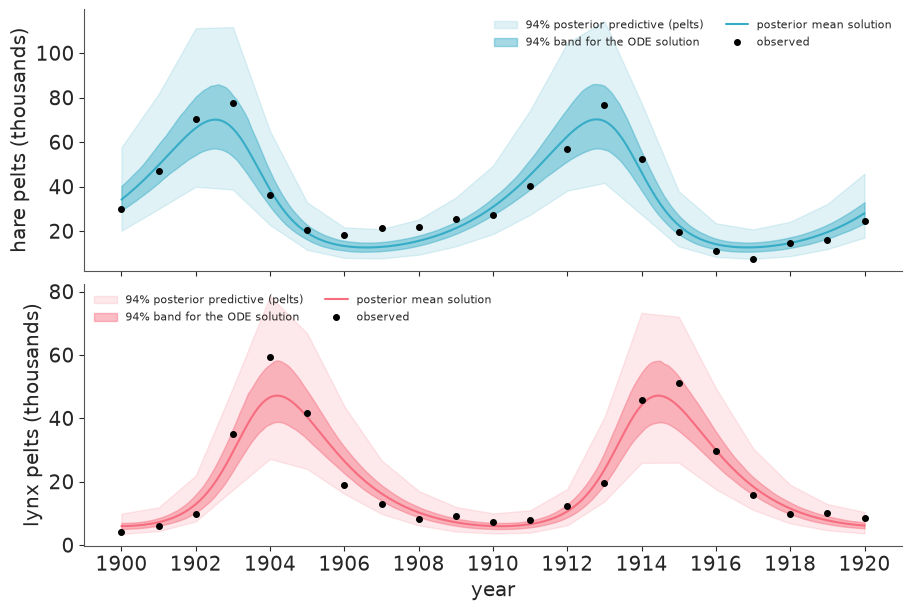

In [34]:
pp = idata.posterior_predictive["pelts"]
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
for i, (ax, species) in enumerate(zip(axes, ["hare", "lynx"])):
    lo, hi = np.quantile(pp.sel(species=species).values, [0.03, 0.97], axis=(0, 1))
    ax.fill_between(pelts.Year, lo, hi, color=f"C{i}", alpha=0.15, label="94% posterior predictive (pelts)")
    lo, hi = np.quantile(dense[:, :, i], [0.03, 0.97], axis=0)
    ax.fill_between(t_dense, lo, hi, color=f"C{i}", alpha=0.45, label="94% band for the ODE solution")
    ax.plot(t_dense, dense[:, :, i].mean(axis=0), color=f"C{i}", label="posterior mean solution")
    ax.plot(pelts.Year, pelts[species.capitalize()], "ko", ms=4, label="observed")
    ax.set(ylabel=f"{species} pelts (thousands)")
    ax.legend(fontsize=8, ncols=2)
axes[1].set(xlabel="year", xticks=pelts.Year[::2])

inside = (obs >= np.quantile(pp.values, 0.03, axis=(0, 1))) & (obs <= np.quantile(pp.values, 0.97, axis=(0, 1)))
print(f"observations inside the 94% predictive band: {inside.sum()} of {inside.size}")

The two-parameter-per-species mechanistic model reproduces both cycles - timing, amplitude
and the lag of lynx behind hares - and 41 of the 42 observations fall inside the 94%
predictive band (about 39 expected). The inner band is uncertainty about the *solution*;
the outer one adds the multiplicative observation noise, $\sigma \approx 0.25$. Note what
the model cannot do: every cycle is identical, so the lower second lynx peak is
attributed to noise.

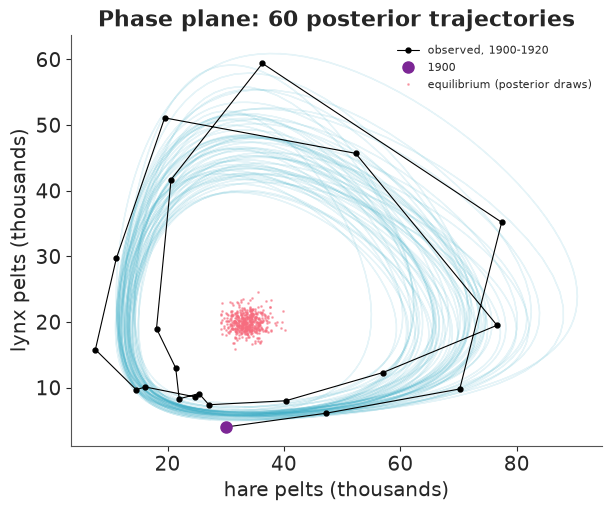

In [35]:
fig, ax = plt.subplots(figsize=(6, 5))
for traj in dense[:60]:
    ax.plot(traj[:, 0], traj[:, 1], color="C0", alpha=0.12, lw=1)
ax.plot(obs[:, 0], obs[:, 1], "k.-", lw=0.8, ms=7, label="observed, 1900-1920")
ax.plot(*obs[0], "o", color="C3", ms=8, label="1900")
eq_hare = (idata.posterior["gamma"] / idata.posterior["delta"]).values.ravel()
eq_lynx = (idata.posterior["alpha"] / idata.posterior["beta"]).values.ravel()
ax.plot(eq_hare[:500], eq_lynx[:500], ".", color="C1", ms=2, alpha=0.5, label="equilibrium (posterior draws)")
ax.set(xlabel="hare pelts (thousands)", ylabel="lynx pelts (thousands)", title="Phase plane: 60 posterior trajectories")
ax.legend(fontsize=8);

In the phase plane the Lotka-Volterra solution is a closed orbit, traversed
counter-clockwise: hares rise, then lynx, then hares crash, then lynx. The data circle the
same region in the same direction, noisily. Derived quantities come with full uncertainty:

In [36]:
post = idata.posterior
derived = {
    "equilibrium hares  gamma/delta": post["gamma"] / post["delta"],
    "equilibrium lynx   alpha/beta": post["alpha"] / post["beta"],
    "small-oscillation period 2pi/sqrt(alpha gamma)": 2 * np.pi / np.sqrt(post["alpha"] * post["gamma"]),
}
# the actual orbits are not small: measure the time between the two hare peaks on the dense grid
peak_gap = (100 + dense[:, 100:, 0].argmax(axis=1) - dense[:, :100, 0].argmax(axis=1)) / 10
for label, values in derived.items():
    lo, hi = az.hdi(values, prob=0.94).values
    print(f"{label:<48} {float(values.mean()):6.2f}   94% HDI [{lo:.2f}, {hi:.2f}]")
print(f"{'years between the two hare peaks (from the orbits)':<48} {peak_gap.mean():6.2f}   "
      f"94% interval [{np.quantile(peak_gap, 0.03):.2f}, {np.quantile(peak_gap, 0.97):.2f}]")
print(f"{'observed mean hares, lynx':<48} {mean_hare:6.2f}, {mean_lynx:.2f}")

equilibrium hares  gamma/delta                    33.53   94% HDI [29.48, 37.50]
equilibrium lynx   alpha/beta                     19.86   94% HDI [17.44, 22.44]
small-oscillation period 2pi/sqrt(alpha gamma)     9.56   94% HDI [9.26, 9.86]
years between the two hare peaks (from the orbits)  10.26   94% interval [10.00, 10.60]
observed mean hares, lynx                         34.08, 20.17


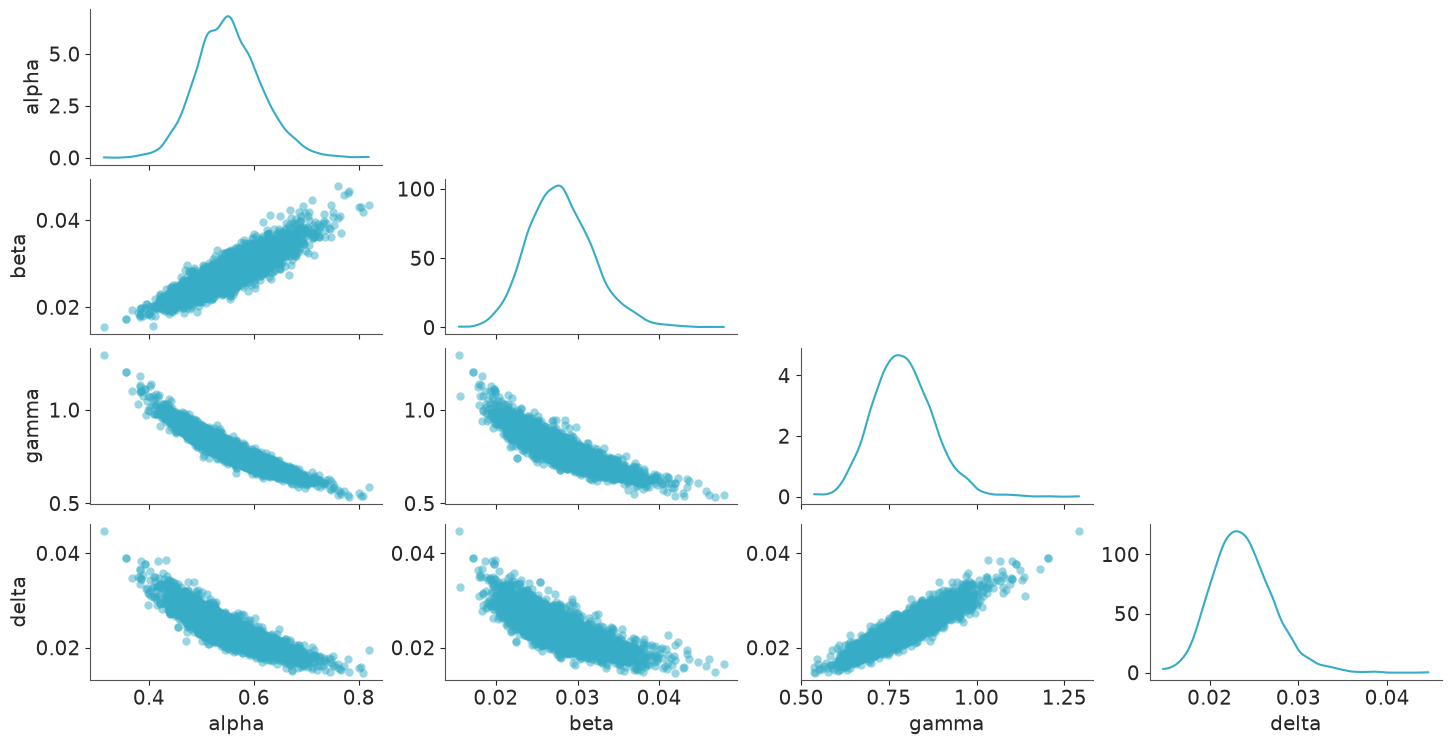

In [37]:
az.plot_pair(idata, var_names=RATES);

In [38]:
flat = az.extract(idata, var_names=RATES).to_dataframe()[RATES]
flat.corr().round(2)

,alpha,beta,gamma,delta
alpha,1.00,0.89,-0.94,-0.88
beta,0.89,1.00,-0.89,-0.79
gamma,-0.94,-0.89,1.00,0.91
delta,-0.88,-0.79,0.91,1.00


The posterior equilibrium sits on the observed mean populations, as the theory says it
should, and the period is pinned down to a few months. That is also the explanation of
the correlations, which reach -0.94: the data determine the *period* (roughly the product
$\alpha\gamma$, hence the negative correlation between $\alpha$ and $\gamma$) and the
*equilibria* (the ratios $\alpha/\beta$ and $\gamma/\delta$, hence the positive ones) much
better than any single rate. A diagonal mass matrix cannot represent such a posterior;
the low-rank adaptation can, which is where the four-fold gain in ESS came from.

## 10 · What can go wrong

Everything in this section happened while this notebook was being written.

**1. Multimodality from a bad start** - section 8. The defaults are not safe for
oscillatory models: start from a physically motivated point.

**2. NaNs and infinities at extreme parameter values.** During warm-up the sampler visits
places the posterior never would. To see what the solvers do there, draw rates from a
deliberately sloppy prior (half-normal with scales 2, 0.5, 2, 0.5) and solve on the
natural scale *and* on the log scale:

In [39]:
def lv_rhs_natural(t, z, theta):
    alpha, beta, gamma, delta = theta
    hare, lynx = z
    return jnp.stack([(alpha - beta * lynx) * hare, (-gamma + delta * hare) * lynx])


def rk4_natural(theta, z0, dt=0.05):
    def step(z, _):
        k1 = lv_rhs_natural(0.0, z, theta)
        k2 = lv_rhs_natural(0.0, z + 0.5 * dt * k1, theta)
        k3 = lv_rhs_natural(0.0, z + 0.5 * dt * k2, theta)
        k4 = lv_rhs_natural(0.0, z + dt * k3, theta)
        z = z + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
        return z, z

    return jax.lax.scan(step, z0, None, length=int(N_YEARS / dt))[1][19::20]


def tsit5_natural(theta, z0):
    return dfx.diffeqsolve(
        dfx.ODETerm(lv_rhs_natural), dfx.Tsit5(), t0=0.0, t1=float(N_YEARS), dt0=0.1, y0=z0, args=theta,
        saveat=dfx.SaveAt(ts=T_OBS), stepsize_controller=dfx.PIDController(rtol=1e-6, atol=1e-6),
        max_steps=4096, throw=False,
    ).ys


n_wild = 2000
wild_theta = jnp.asarray(np.abs(rng.normal(0, [2, 0.5, 2, 0.5], size=(n_wild, 4))))
wild_z0 = jnp.asarray(np.exp(rng.normal(np.log(10), 1, size=(n_wild, 2))))

rows = {}
for label, solve, is_log in [
    ("RK4, natural scale", rk4_natural, False), ("Tsit5, natural scale", tsit5_natural, False),
    ("RK4, log scale", lv_rk4, True), ("Tsit5, log scale", lv_tsit5, True),
]:
    out = np.asarray(jax.jit(jax.vmap(solve))(wild_theta, wild_z0))
    nonfinite = ~np.isfinite(out).all(axis=(1, 2))
    smallest = out[~nonfinite].min()
    rows[label] = {
        "draws with inf/NaN": int(nonfinite.sum()),
        # on the log scale exp(.) cannot be negative, whatever the solver returns
        "finite, but a population <= 0": 0 if is_log else int((out[~nonfinite] <= 0).any(axis=(1, 2)).sum()),
        "smallest population returned": f"exp({smallest:.0f})" if is_log else f"{smallest:.2g}",
    }
wild_table = pd.DataFrame(rows).T
wild_table

,draws with inf/NaN,"finite, but a population <= 0",smallest population returned
"RK4, natural scale",14,0,5.4e-212
"Tsit5, natural scale",3,377,-63
"RK4, log scale",0,0,exp(-9229)
"Tsit5, log scale",0,0,exp(-1639)


In [40]:
rk4_log_out = np.asarray(jax.jit(jax.vmap(lv_rk4))(wild_theta, wild_z0))
tsit5_log_out = np.asarray(jax.jit(jax.vmap(lv_tsit5))(wild_theta, wild_z0))
both_finite = np.isfinite(rk4_log_out).all(axis=(1, 2)) & np.isfinite(tsit5_log_out).all(axis=(1, 2))
gap = np.abs(rk4_log_out - tsit5_log_out)[both_finite].max(axis=(1, 2))
print("max |RK4 - Tsit5| on the log scale: median %.1e, 90th pct %.1e, 99th pct %.1e"
      % tuple(np.quantile(gap, [0.5, 0.9, 0.99])))

max |RK4 - Tsit5| on the log scale: median 3.5e-04, 90th pct 1.0e-01, 99th pct 6.2e+00


On the natural scale the fixed-step RK4 overflows on 14 of the 2000 draws. The adaptive
solver fails on 3 and returns *negative populations* on 377 more. A population that
crashes towards zero is only accurate to `atol`, so it can step just below zero; then the
sign of its growth term flips and it runs away (the most negative value here is -63). The
logarithm in the likelihood turns all of those into NaN. On the log scale neither
happens: a crash is just a large negative number.

That does not make the fixed-step solver *right* in those corners: there it differs from
the adaptive solution by a factor of $e^{6}$ at the 99th percentile. A fixed step never
fails; it is just silently wrong where the dynamics are fast. Here those regions carry no
posterior mass - the RK4 and diffrax posteriors in section 8 agree - but that comparison
is the check to make before trusting a fixed-step solver on a new problem.

**3. `max_steps` and `throw`.** An adaptive solver in a stiff corner can need more steps
than its budget. diffrax then either raises, which kills the sampler from inside a callback,
or - with `throw=False` - returns `inf`, which NUTS treats as a rejected proposal
and moves on. For sampling you want the second behaviour:

In [41]:
theta_hard = wild_theta[int(np.argmax(np.asarray(wild_theta[:, 0] * wild_theta[:, 2])))]  # fastest dynamics
for throw in [True, False]:
    solve = make_diffrax(max_steps=100, throw=throw)
    try:
        result = solve(theta_hard, jnp.array([10.0, 10.0]))
        print(f"throw={throw}: returned, last row = {np.asarray(result)[-1]}")
    except Exception as err:
        message = [line for line in str(err).splitlines() if "max_steps" in line]
        print(f"throw={throw}: {type(err).__name__}: {message[0].strip() if message else str(err)[:100]}")

throw=True: EquinoxRuntimeError: equinox.EquinoxRuntimeError: The maximum number of solver steps was reached. Try increasing `max_steps`.


throw=False: returned, last row = [inf inf]


**4. Tracers, Python control flow and dynamic shapes.** `wrap_jax` traces your function
when the graph is built, so the usual JAX rules apply, and they bite at model-definition
time. Branch on a value with `jnp.where`/`lax.cond`, not `if`; shapes must not depend on
values; and `lax.while_loop` cannot be reverse-differentiated - use `lax.scan`, a bounded
loop, or a library that implements an adjoint (diffrax, optimistix, lineax):

In [42]:
def python_branch(x):
    return x if x > 0 else -x


def value_dependent_shape(n):
    return jnp.arange(n)


def newton_sqrt(x):  # iterate until converged: natural to write, impossible to reverse-differentiate
    def not_converged(state):
        return jnp.abs(state * state - x) > 1e-12

    return jax.lax.while_loop(not_converged, lambda s: 0.5 * (s + x / s), x)


failures = {
    "Python `if` on a traced value": lambda: pytensor.wrap_jax(python_branch)(pt.dscalar("x")),
    "shape depends on a value": lambda: pytensor.wrap_jax(value_dependent_shape)(pt.lscalar("n")),
    "jax.grad through lax.while_loop": lambda: jax.grad(newton_sqrt)(2.0),
}
print("newton_sqrt(2.0) =", float(newton_sqrt(2.0)), "(the forward pass is fine)\n")
for label, attempt in failures.items():
    try:
        attempt()
        print(f"{label}: worked?!")
    except Exception as err:
        print(f"{label}:\n    {type(err).__name__}: {str(err).splitlines()[0][:120]}")

newton_sqrt(2.0) = 1.414213562373095 (the forward pass is fine)

Python `if` on a traced value:
    TracerBoolConversionError: Attempted boolean conversion of traced array with shape bool[].
shape depends on a value:
    ConcretizationTypeError: Abstract tracer value encountered where concrete value is expected: traced array with shape int64[]
jax.grad through lax.while_loop:
    ValueError: Reverse-mode differentiation does not work for lax.while_loop or lax.fori_loop with dynamic start/stop values. Try using


**5. Silent float32** - section 3. If the first cell had not enabled x64, every number in
this notebook would have been computed in single precision without a single error.

**6. PyMC's own NUTS and `fork`.** With `nuts_sampler="pymc"` the chains run in separate
*processes*. On this machine (macOS, Apple silicon) PyMC starts them with `fork`, and a
forked copy of an initialised, multithreaded JAX runtime deadlocks: the sampler sat at 0%
CPU for nine minutes until I killed it. PyMC switches to a safe start method by itself
when the *backend* is JAX, but it cannot know that a Numba-mode graph hides a JAX call.
`pm.sample(nuts_sampler="pymc", mp_ctx="spawn")` or `cores=1` both worked. nutpie and
NumPyro run their chains in threads of one process, so they never meet the problem.

## 11 · Summary

- NUTS needs gradients; an external function is a black box until you wrap it in an `Op`
  with a `pullback`. If the function is written in JAX, `jax.vjp` *is* the pullback.
- `pytensor.wrap_jax` writes both `Op`s and the JAX-backend registration for you. Give it
  inputs with static shapes (`pt.specify_shape`) and enable x64.
- The same wrapped model runs under the default Numba backend (JAX via callback), under
  nutpie's JAX backend and under NumPyro. Measure before assuming which one is fastest.
- For ODE models: integrate on a scale where the state cannot leave its domain, start the
  sampler from a physically motivated point, and expect correlated rate parameters.

### Try it yourself

1. **An implicit function.** The Lotka-Volterra orbit conserves
   $H(u, v) = \delta u - \gamma \log u + \beta v - \alpha \log v$. The peak hare population
   $u_{\max}$ is the larger root of $H(u, \alpha/\beta) = H(u_0, v_0)$. Write a JAX function
   that finds it by Newton iteration (a fixed number of steps in a `lax.scan`, or a
   `lax.while_loop`), give it a `jax.custom_vjp` from the implicit function theorem,
   $\partial u_{\max}/\partial\theta = -(\partial H/\partial u)^{-1}\,\partial H/\partial\theta$,
   wrap it with `wrap_jax`, and add `u_max` to the model as a `pm.Deterministic`. Check the
   gradient with `verify_grad` against differentiating through the unrolled iterations.
2. **A better ecological model.** Hares do not grow without bound in the absence of lynx.
   Add a carrying capacity, $\dot{u} = \alpha u (1 - u/K) - \beta u v$, with a prior on $K$
   justified on the scale of the data. Compare the two models with `az.compare` (you need
   `pm.compute_log_likelihood` first; it works with a wrapped function). Expect a Pareto-k
   warning or two with only 42 observations - what does that tell you?
3. **Swap the solver, measure the effect.** Re-run the timing table with `dfx.Dopri5()`,
   with `tol=1e-3` and `tol=1e-9`, and with `BacksolveAdjoint`. How far can you loosen the
   tolerance before the posterior moves or divergences appear? Then go the other way: how
   few RK4 steps per year can you get away with?

Next: **E10** confronts another physical model with real detector data - LIGO's GW150914.